Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import seaborn as sns
import joblib

Load Data

In [10]:
# Load CSV datasets
train_df = pd.read_csv("../data/train_motion_data.csv")
test_df = pd.read_csv("../data/test_motion_data.csv")

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
train_df.head()

Training Data Shape: (3644, 8)
Testing Data Shape: (3084, 8)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631


Data Cleaning

In [11]:
cols = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
for c in cols:
    train_df[c] = savgol_filter(train_df[c], window_length=7, polyorder=3)
    test_df[c] = savgol_filter(test_df[c], window_length=7, polyorder=3)

Windowing Function

In [12]:
WINDOW_SIZE = 100
STRIDE = 20

def create_windows(df):
    sequences = []
    labels = []
    for i in range(0, len(df) - WINDOW_SIZE, STRIDE):
        window = df.iloc[i:i+WINDOW_SIZE][cols].values
        label = df.iloc[i+WINDOW_SIZE-1]['Class']
        sequences.append(window)
        labels.append(label)
    return np.array(sequences), np.array(labels)

X_train, y_train = create_windows(train_df)
X_test, y_test = create_windows(test_df)

Encode Labels

In [13]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

Scaling

In [14]:
# Scale features per-column
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scalers = {}
for i, c in enumerate(cols):
    s = StandardScaler()
    X_train_scaled[:, :, i] = s.fit_transform(X_train[:, :, i])
    X_test_scaled[:, :, i] = s.transform(X_test[:, :, i])
    scalers[c] = s

Baseline Models

In [16]:
def extract_features_enhanced(X):
    features = []
    for window in X:
        feats = []
        for i in range(window.shape[1]):
            w = window[:, i]
            # Basic stats
            feats.extend([w.mean(), w.std(), w.min(), w.max()])
            # Energy and power
            feats.append(np.sqrt((w**2).sum()))
            # Shape descriptors
            feats.extend([skew(w), kurtosis(w)])
            # Temporal dynamics
            feats.append(np.mean(np.diff(w))) # average derivative
            feats.append(np.std(np.diff(w))) # derivative variability
        features.append(feats)
    return np.array(features)

X_train_feat = extract_features_enhanced(X_train_scaled)
X_test_feat = extract_features_enhanced(X_test_scaled)

# Rebalance using SMOTE
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_feat, y_train_enc)

# Compute class weights
cw = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weights = {i: cw[i] for i in range(len(cw))}

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_feat, y_train_enc)
lr_preds = lr.predict(X_test_feat)

lr_proba = lr.predict_proba(X_test_feat)
lr_loss = log_loss(y_test_enc, lr_proba)

print("Logistic Regression Report:")
print(classification_report(y_test_enc, lr_preds))
print(f"Logistic Regression Log Loss: {lr_loss:.4f}")


# Random Forest
rf_params = {
'n_estimators': 500,
'max_depth': 40,
'min_samples_split': 5,
'min_samples_leaf': 2,
'max_features': 'sqrt',
'class_weight': 'balanced_subsample',
'random_state': 42
}

rf = RandomForestClassifier(**rf_params)
rf.fit(X_train_bal, y_train_bal)
rf_preds = rf.predict(X_test_feat)

rf_proba = rf.predict_proba(X_test_feat)
rf_loss = log_loss(y_test_enc, rf_proba)

print("Random Forest Report:")
print(classification_report(y_test_enc, rf_preds))
print(f"Random Forest Log Loss: {rf_loss:.4f}")

# XGBoost
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=0.8,
    subsample=0.9,
    gamma=0.1,
    eval_metric='mlogloss',
    tree_method='hist'
)
xgb.fit(X_train_bal, y_train_bal)
xgb_preds = xgb.predict(X_test_feat)

xgb_proba = xgb.predict_proba(X_test_feat)
xgb_loss = log_loss(y_test_enc, xgb_proba)

print("XGBoost Report:")
print(classification_report(y_test_enc, xgb_preds))
print(f"XGBoost Log Loss: {xgb_loss:.4f}")

# LightGBM
lgb_params = {
'objective': 'multiclass',
'num_class': 3,
'learning_rate': 0.05,
'num_leaves': 63,
'feature_fraction': 0.8,
'bagging_fraction': 0.8,
'bagging_freq': 5,
'min_child_samples': 10,
'metric': 'multi_logloss',
'is_unbalance': True,
'verbose': -1
}

lgb_train = lgb.Dataset(X_train_bal, label=y_train_bal)
lgb_model = lgb.train(lgb_params, lgb_train)
lgb_preds = np.argmax(lgb_model.predict(X_test_feat), axis=1)

lgb_proba = lgb_model.predict(X_test_feat)
lgb_loss = log_loss(y_test_enc, lgb_proba)

print("LightGBM Report:")
print(classification_report(y_test_enc, lgb_preds))
print(f"LightGBM Log Loss: {lgb_loss:.4f}")

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        36
           1       0.51      0.44      0.47        50
           2       0.74      0.75      0.74        64

    accuracy                           0.67       150
   macro avg       0.65      0.67      0.66       150
weighted avg       0.66      0.67      0.66       150

Logistic Regression Log Loss: 0.9885
Random Forest Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85        36
           1       0.47      0.38      0.42        50
           2       0.68      0.70      0.69        64

    accuracy                           0.65       150
   macro avg       0.64      0.68      0.65       150
weighted avg       0.63      0.65      0.64       150

Random Forest Log Loss: 0.6626
XGBoost Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.82      

Save Models

In [8]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"],
    "Precision": [
        classification_report(y_test_enc, lr_preds, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test_enc, rf_preds, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test_enc, xgb_preds, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test_enc, lgb_preds, output_dict=True)['weighted avg']['precision']
    ],
    "Recall": [
        classification_report(y_test_enc, lr_preds, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test_enc, rf_preds, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test_enc, xgb_preds, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test_enc, lgb_preds, output_dict=True)['weighted avg']['recall']
    ],
    "F1-Score": [
        classification_report(y_test_enc, lr_preds, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test_enc, rf_preds, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test_enc, xgb_preds, output_dict=True)['weighted avg']['f1-score'],
        classification_report(y_test_enc, lgb_preds, output_dict=True)['weighted avg']['f1-score']
    ],
    "Accuracy": [
        (lr_preds == y_test_enc).mean(),
        (rf_preds == y_test_enc).mean(),
        (xgb_preds == y_test_enc).mean(),
        (lgb_preds == y_test_enc).mean()
    ],
    "Log Loss": [lr_loss, rf_loss, xgb_loss, lgb_loss]
})

results.to_csv('../models/results.csv')
print(results)

joblib.dump(lr, '../models/logistic_regression.pkl')
joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost.pkl')
joblib.dump(scalers, '../models/scalers.pkl')

                 Model  Precision    Recall  F1-Score  Accuracy  Log Loss
0  Logistic Regression   0.657048  0.666667  0.659841  0.666667  0.988511
1        Random Forest   0.634697  0.653333  0.640125  0.653333  0.662583
2              XGBoost   0.705651  0.700000  0.698503  0.700000  0.793788
3             LightGBM   0.660309  0.666667  0.658795  0.666667  0.841273


['../models/scalers.pkl']

Confusion Matrix Plot Function

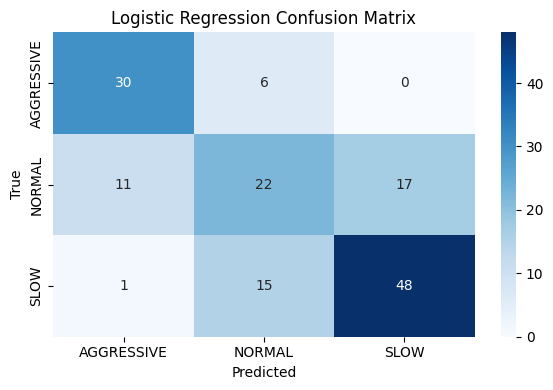

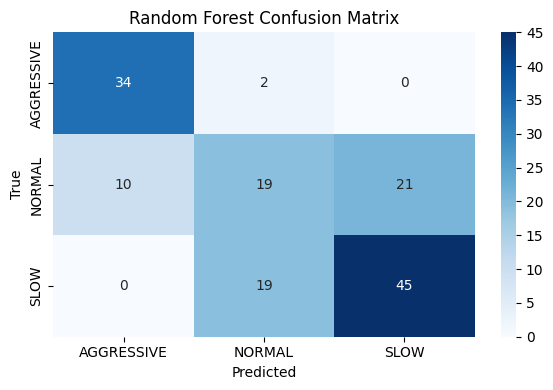

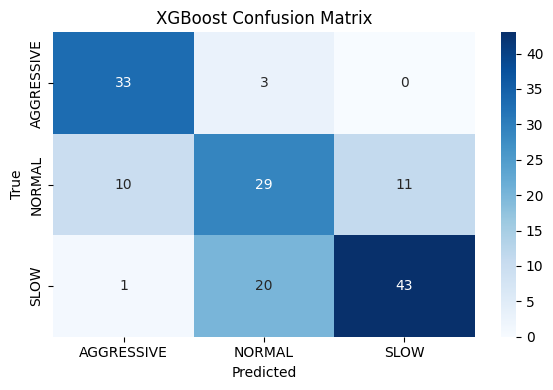

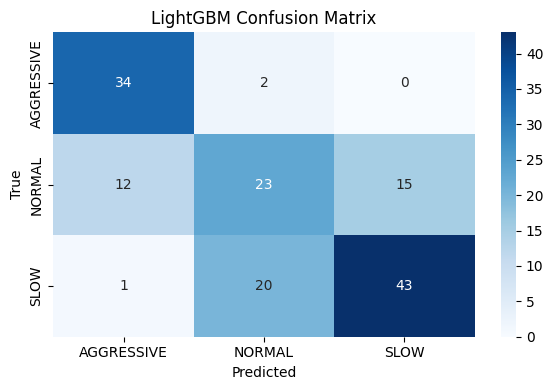

In [18]:
def plot_confusion(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices
plot_confusion('Logistic Regression', y_test_enc, lr_preds)
plot_confusion('Random Forest', y_test_enc, rf_preds)
plot_confusion('XGBoost', y_test_enc, xgb_preds)
plot_confusion('LightGBM', y_test_enc, lgb_preds)